<a href="https://colab.research.google.com/github/simulate111/Computer-vision2026ABO/blob/main/CompViz_part_II_nr_5_ipynb_txt.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# IT00CJ11 Computer Vision (5 cr. ECTS), spring 2025

***Direct computational methods and deep learning for vision***

*This notebook follows the blog published by Guilherme Caponetto on towardsdatascience.com*

***Object detection***

In 2019, Google announced the 5th release of Open Images Dataset (OID) along with some pre-trained models for the object detection task. Let’s play with one of those models and check how it visually performs.

Introduction

Roughly, the latest version of OID is composed of 15M annotated bounding boxes on 601 categories, 2.5M instance segmentations on 350 categories, 36M image-level labels on 20k categories, and 391k relationship annotations of 329 relationships. That’s a pretty massive amount of data, surely enabling many computer vision research possibilities.

Putting our focus on the object detection task, the goal is not only labeling an image as having a particular object but also detecting with high confidence a bounding box around the object. One famous approach that you might have heard of is YOLO (You Only Look Once), currently on version 3.

As mentioned, some models pre-trained on OID have been released. The latest ones were trained on the version 4 of the dataset, and I will be playing with the best one (in terms of mAP)— and slower (in terms of speed)— in this post. These models and many others can be found on the Tensorflow detection model zoo repository.

It’s important to highlight that the intention of this post is playing with object detection, i.e. making a visual assessment of the output. Also, I want to provide an easy-to-follow code for those who are interested in getting started with this area. However, discussing the research area or diving into algorithm details is out of the scope of this notebook.

We start with configuring matplotlib to display images inline for our jupyter notebook.

In [ ]:
import matplotlib.pyplot as plt

%matplotlib inline

We’ll need some libraries to deal with files, so here are the imports. I’m also importing numpy since we’ll be using it throughout the notebook. For tensorflow, we need to disable som of the new version characteristics in order to use some subroutines below.

In [ ]:
import os

import urllib
import tarfile

import numpy as np
import tensorflow.compat.v1 as tf
tf.disable_v2_behavior()

Instructions for updating:
non-resource variables are not supported in the long term


Now, we can download the model suitable for our data. Information on configuration can be found here: https://github.com/tensorflow/models/blob/master/research/object_detection/samples/configs/faster_rcnn_inception_resnet_v2_atrous_oid_v4.config

In [ ]:
MODEL_DOWNLOAD_BASE = 'http://download.tensorflow.org/models/object_detection/'
MODEL_NAME = 'faster_rcnn_inception_resnet_v2_atrous_oid_v4_2018_12_12'
MODEL_FILE = MODEL_NAME + '.tar.gz'

if os.path.exists(MODEL_FILE) is False:
    opener = urllib.request.URLopener()
    opener.retrieve(MODEL_DOWNLOAD_BASE + MODEL_FILE, MODEL_FILE)

We also need the box description file. As you’ll see, the inference code will return some numbers corresponding to the classes (1 to 601). Thus, we need this description file to map the resulting number with human-readable class name. Similar to the model file, it won’t be downloaded if the file exists. Notice that, every class is treated as an object, such as animals and people.

In [ ]:
BOX_DESCRIPTIONS_FILE = 'class-descriptions-boxable.csv'
OID_DOWNLOAD_BASE = 'https://storage.googleapis.com/openimages/2018_04/'

if os.path.exists(BOX_DESCRIPTIONS_FILE) is False:
    opener = urllib.request.URLopener()
    opener.retrieve(OID_DOWNLOAD_BASE + BOX_DESCRIPTIONS_FILE, BOX_DESCRIPTIONS_FILE)

If you are curious about the 601 classes available in OID for object detection, check out this:
https://storage.googleapis.com/openimages/2018_04/bbox_labels_600_hierarchy_visualizer/circle.html

Getting some test images

I’ve prepared the notebook for those who want to just run it and see the results, and possibly do some customization. In fact, it is based on some code from the Tensorflow models repository, but it's modified to make it simple for everyone to understand. Thus, continuing to simplify things to you, the following code will download some test images. Feel free to change the URLs so you can test with other images.

In [ ]:
TEST_IMAGES = {
    'cat.jpg': 'https://c2.staticflickr.com/7/6118/6370710013_cb6b0270d3_o.jpg',
    'dog.jpg': 'https://c3.staticflickr.com/1/92/246323809_f8a8ab71fe_o.jpg',
    'pets.jpg': 'https://live.staticflickr.com/3273/2982384735_eeecaf03f2_b.jpg'
}

for filename, url in TEST_IMAGES.items():
    if os.path.exists(filename) is False:
        opener = urllib.request.URLopener()
        opener.retrieve(url, filename)

Extracting the model files

Now that all necessary files are in place, let’s extract the files from the compressed model file so that we can have access to the inference frozen graph. This file is optimized for inference, i.e. all training stuff is removed.

In [ ]:
FROZEN_GRAPH_FILE = 'frozen_inference_graph.pb'
PATH_TO_FROZEN_GRAPH = os.path.join(MODEL_NAME, FROZEN_GRAPH_FILE)

if os.path.exists(MODEL_NAME) is False:
    tar_file = tarfile.open(MODEL_FILE)
    for file in tar_file.getmembers():
        filename = os.path.basename(file.name)
        if FROZEN_GRAPH_FILE in filename:
            tar_file.extract(file, os.getcwd())

Loading the box descriptions into a dictionary

Let’s create a dictionary to map the classes, where the key is simply the index and the value is another dictionary, which contains the class id and name as key and value, respectively.

In [ ]:
import pandas as pd

ID_KEY = 'id'
CLASS_KEY = 'class'
NAME_KEY = 'name'

df = pd.read_csv(BOX_DESCRIPTIONS_FILE, names=[ID_KEY, CLASS_KEY])
category_index = {}
for idx, row in df.iterrows():
    category_index[idx+1] = {ID_KEY: row[ID_KEY], NAME_KEY: row[CLASS_KEY]}

Checking some labels

This is how the classes are mapped, however, we won’t be using the id. Instead, we’ll be using the index to make it easier. Just to exemplify, if we get class #100, then it corresponds to Cheese.

In [ ]:
print(category_index[1])   # {'id': '/m/011k07', 'name': 'Tortoise'}
print(category_index[100]) # {'id': '/m/01nkt', 'name': 'Cheese'}
print(category_index[300]) # {'id': '/m/04_sv', 'name': 'Motorcycle'}
print(category_index[601]) # {'id': '/m/0zvk5', 'name': 'Helmet'}

{'id': '/m/011k07', 'name': 'Tortoise'}
{'id': '/m/01nkt', 'name': 'Cheese'}
{'id': '/m/04_sv', 'name': 'Motorcycle'}
{'id': '/m/0zvk5', 'name': 'Helmet'}


Loading the frozen model from file

Now we need to create our graph from the frozen model file.

In [ ]:
graph = tf.Graph()
with graph.as_default():
    graph_def = tf.GraphDef()
    with tf.gfile.GFile(PATH_TO_FROZEN_GRAPH, 'rb') as fid:
        serialized_graph = fid.read()
        graph_def.ParseFromString(serialized_graph)
        tf.import_graph_def(graph_def, name='')

Checking original test images

The following code snippet defines a helper function that shows images with their filename set as the title. Then, it goes through every test image and shows it.

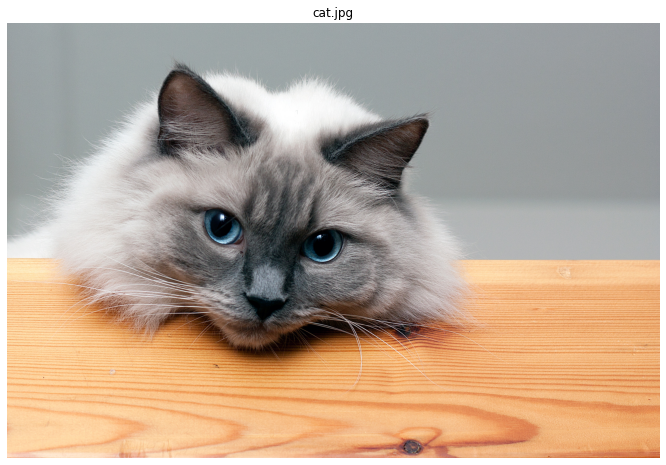

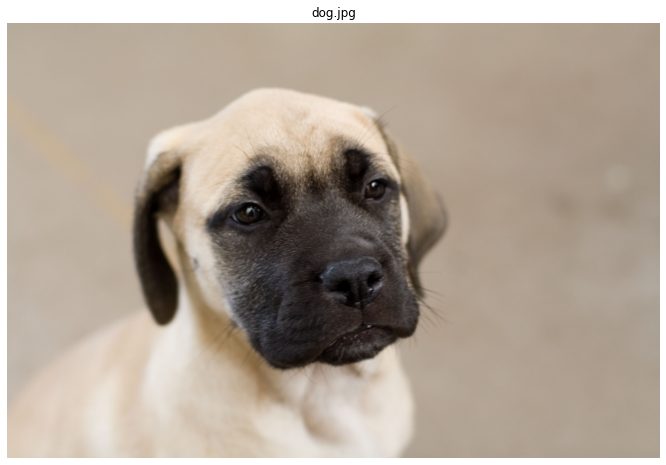

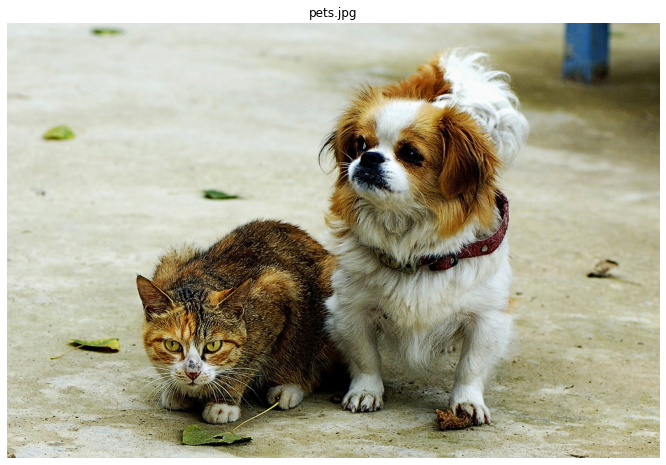

In [ ]:
from PIL import Image

IMAGE_SIZE = (12, 8)


def show_image(filename, image):
    """
    Shows the given image with its filename as title.
    :param filename: image filename
    :param image: image to show
    """
    plt.figure(figsize=IMAGE_SIZE)
    plt.title(filename)
    plt.axis('off')
    plt.imshow(image)


for filename, _ in TEST_IMAGES.items():
    original_image = Image.open(filename)
    show_image(filename, original_image)

Defining some helper code

We’ll need some more helper code.

In [ ]:
# Font to draw text on image
FONT_NAME = 'Ubuntu-R.ttf'

# Bounding box colors
COLORS = ['Green',
          'Red', 'Pink',
          'Olive', 'Brown', 'Gray',
          'Cyan', 'Orange']

In [ ]:
class ObjectResult:
    """
    Represents a detection result, containing the object label,
    score confidence, and bounding box coordinates.
    """

    def __init__(self, label, score, box):
        self.label = label
        self.score = score
        self.box = box

    def __repr__(self):
        return '{0} ({1}%)'.format(self.label, int(100 * self.score))

In [ ]:
N_CHANNELS = 3


def load_image_into_numpy_array(image):
    """
    Converts a PIL image into a numpy array (height x width x channels).
    :param image: PIL image
    :return: numpy array
    """
    (width, height) = image.size
    return np.array(image.getdata()) \
        .reshape((height, width, N_CHANNELS)).astype(np.uint8)

In [ ]:
def process_output(classes, scores, boxes, category_index):
    """
    Processes classes, scores, and boxes, gathering in a list of ObjectResult.
    :param classes: list of class id
    :param scores: list of scores
    :param boxes: list of boxes
    :param category_index: label dictionary
    :return: list of ObjectResult
    """
    results = []

    for clazz, score, box in zip(classes, scores, boxes):
        if score > 0.0:
            label = category_index[clazz][NAME_KEY]
            obj_result = ObjectResult(label, score, box)
            results.append(obj_result)

    return results

In [ ]:
import random

import PIL.Image as Image


def draw_labeled_boxes(image_np, results, min_score=.4):
    """
    Draws labeled boxes according to results on the given image.
    :param image_np: numpy array image
    :param results: list of ObjectResult
    :param min_score: optional min score threshold, default is 40%
    :return: numpy array image with labeled boxes drawn
    """
    results.sort(key=lambda x: x.score, reverse=False)
    image_np_copy = image_np.copy()
    for r in results:
        if r.score >= min_score:
            color_idx = random.randint(0, len(COLORS) - 1)
            color = COLORS[color_idx]

            image_pil = Image.fromarray(np.uint8(image_np_copy)).convert('RGB')
            draw_bounding_box_on_image(image_pil, r.box, color, str(r))
            np.copyto(image_np_copy, np.array(image_pil))

    return image_np_copy

In [ ]:
import PIL.ImageFont as ImageFont


def get_suitable_font_for_text(text, img_width, font_name, img_fraction=0.12):
    """
    Calculates a suitable font for the image given the text and fraction.
    :param text: text that will be drawn
    :param img_width: width of the image
    :param font_name: name of the font
    :param img_fraction: optional desired image fraction allowed for the text
    :return: suitable font
    """
    fontsize = 1
    font = ImageFont.truetype("arial.ttf", fontsize)
    while font.getsize(text)[0] < img_fraction*img_width:
        fontsize += 1
        font = ImageFont.truetype(font_name, fontsize)
    return font

In [ ]:
import PIL.ImageDraw as ImageDraw

TEXT_COLOR = 'Black'


def draw_bounding_box_on_image(image, box, color, box_label):
    """
    Draws the box and label on the given image.
    :param image: PIL image
    :param box: numpy array containing the bounding box information
                [top, left, bottom, right]
    :param color: bounding box color
    :param box_label: bounding box label
    """
    im_width, im_height = image.size
    top, left, bottom, right = box

    # Normalize coordinates
    left = left * im_width
    right = right * im_width
    top = top * im_height
    bottom = bottom * im_height

    # Draw the detected bounding box
    line_width = int(max(im_width, im_height) * 0.005)
    draw = ImageDraw.Draw(image)
    draw.rectangle(((left, top), (right, bottom)),
                   width=line_width,
                   outline=color)

    # Get a suitable font (in terms of size with respect to the image)
    font = get_suitable_font_for_text(box_label, im_width, "arial.ttf")
    text_width, text_height = font.getsize(box_label)

    # Draw the box label rectangle
    text_bottom = top + text_height
    text_rect = ((left, top),
                 (left + text_width + 2 * line_width,
                  text_bottom + 2 * line_width))
    draw.rectangle(text_rect, fill=color)

    # Draw the box label text
    # right below the upper-left horizontal line of the bounding box
    text_position = (left + line_width, top + line_width)
    draw.text(text_position, box_label, fill=TEXT_COLOR, font=font)

Routine for running the actual object detection:

In [ ]:
# Input tensor
IMAGE_TENSOR_KEY = 'image_tensor'

# Output tensors
DETECTION_BOXES_KEY = 'detection_boxes'
DETECTION_SCORES_KEY = 'detection_scores'
DETECTION_CLASSES_KEY = 'detection_classes'

TENSOR_SUFFIX = ':0'


def run_inference(graph, image_np):
    """
    Runs the inference on the given image.
    :param graph: tensorflow graph
    :param image_np: numpy image
    :return: dictionary with detected classes
             and their corresponding scores and boxes
    """
    output_tensor_dict = {
        DETECTION_BOXES_KEY: DETECTION_BOXES_KEY + TENSOR_SUFFIX,
        DETECTION_SCORES_KEY: DETECTION_SCORES_KEY + TENSOR_SUFFIX,
        DETECTION_CLASSES_KEY: DETECTION_CLASSES_KEY + TENSOR_SUFFIX
    }

    with graph.as_default():
        with tf.Session() as sess:
            input_tensor = tf.get_default_graph()\
                .get_tensor_by_name(IMAGE_TENSOR_KEY + TENSOR_SUFFIX)
            image_np_expanded = np.expand_dims(image_np, axis=0)
            input_tensor_dict = {input_tensor: image_np_expanded}
            output_dict = sess.run(output_tensor_dict,
                                   feed_dict=input_tensor_dict)

            return {
                DETECTION_BOXES_KEY:
                    output_dict[DETECTION_BOXES_KEY][0],
                DETECTION_SCORES_KEY:
                    output_dict[DETECTION_SCORES_KEY][0],
                DETECTION_CLASSES_KEY:
                    output_dict[DETECTION_CLASSES_KEY][0].astype(np.int64)
            }

Running the inference

All set! Let’s run the inference for all test images.

In [ ]:
IMAGE_NP_KEY = 'image_np'
RESULTS_KEY = 'results'

file_result_dict = {}

for filename, _ in TEST_IMAGES.items():
    image_np = load_image_into_numpy_array(Image.open(filename))

    output_dict = run_inference(graph, image_np)

    results = process_output(output_dict[DETECTION_CLASSES_KEY],
                             output_dict[DETECTION_SCORES_KEY],
                             output_dict[DETECTION_BOXES_KEY],
                             category_index)

    file_result_dict[filename] = { IMAGE_NP_KEY: image_np, RESULTS_KEY: results }

In [ ]:
ImageFont.truetype("arial.ttf", 18)

Showing the results

Let’s now draw the labeled bounding boxes according to the results and show the images.

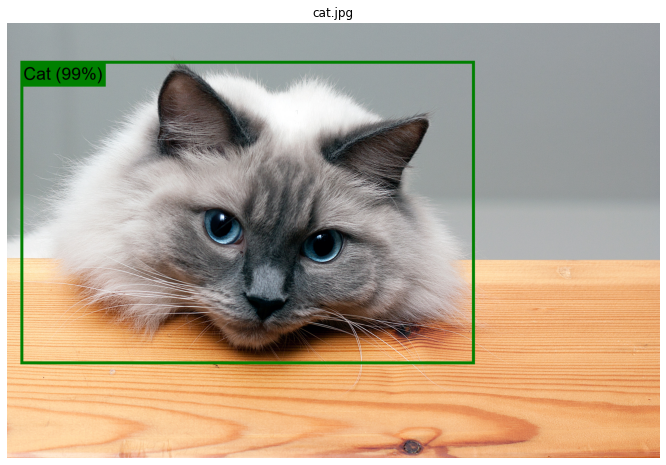

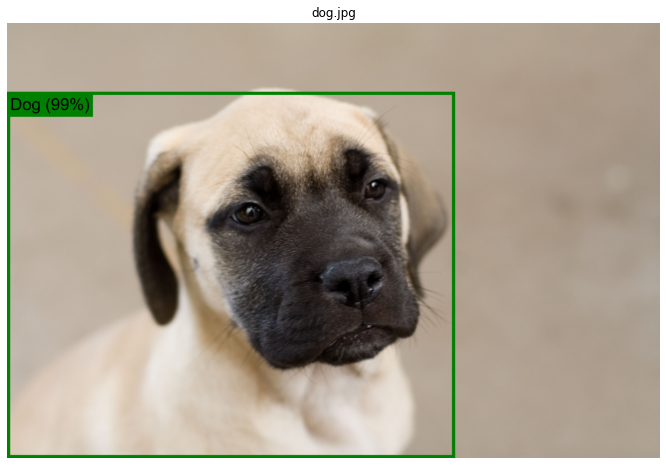

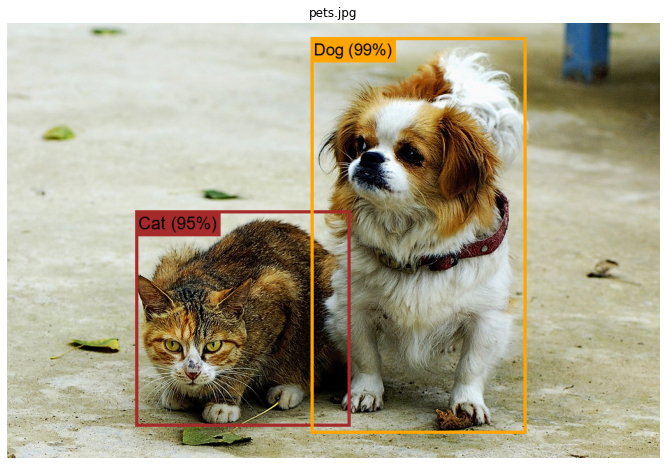

In [ ]:
for filename, img_results_dict in file_result_dict.items():
    processed_image = draw_labeled_boxes(img_results_dict[IMAGE_NP_KEY],img_results_dict[RESULTS_KEY])
    show_image(filename, processed_image)

As we can see, running the inference using this model has provided pretty good results in both detecting the objects of interest with high confidence as well as their corresponding bounding boxes. However, the position of the objects and clean background help a lot, which makes this task not so challenging.

More challenging results

In the real world, you would have situations where the objects are partially overlapped by others, or too small, or even in a position that does not favor their identification, among others. Thus, let’s run the inference on the following images and check out the results.

![image.png](attachment:image.png)

Street: Basically, cars have been detected in this one. I was hoping of getting a Building and maybe Traffic sign. Perhaps the progressive blurry background made it harder, but those traffic signs on the left could definitely have been detected with some reasonable confidence.